In [1]:
from antspynet.utilities import lung_extraction
from monai.networks.blocks import Warp,DVF2DDF
import torch
import ants
import os
import numpy as np
import shutil

def plot_ct(img,slices,overlay=None,title=None):
    if overlay!=None:
        img_over = overlay - overlay.min()
    else:
        img_over = None
        
    img2 = img-img.min()
    img2.plot(axis=1,slices=slices,title=title,overlay=img_over,overlay_alpha=0.5)

def compute_volume(img):
    """
    Computes the area (number of pixels) of a binary mask and multiplies the pixels
    with the pixel dimension of the acquired CT image
    Args:
        lung_mask: binary lung mask
        pixdim: list or tuple with two values
    Returns: the lung area in mm^2
    """
    pixdim = img.spacing
    img = img.numpy()
    # img[img >= 0.5] = 1
    # img[img < 0.5] = 0
    lung_pixels = np.sum(img)
    return lung_pixels * pixdim[0] * pixdim[1]* pixdim[2]

def get_lung_mask(img):
    lung_result = lung_extraction(img, modality='ct', verbose=False)
    left_lung = lung_result['probability_images'][1]
    right_lung = lung_result['probability_images'][2]

    left_lung_volume = compute_volume(left_lung)
    right_lung_volume = compute_volume(right_lung)

    return {"left_lung_volume":left_lung_volume,
            "right_lung_volume":right_lung_volume,
            "left_lung":left_lung,
            "right_lung":right_lung}

In [ ]:
def resample_dff(ddf_npy_filepath_1,ddf_npy_filepath_2,moving_filepath,fixed_filepath,warp,savepath=None,plot=False):
    moving_img = ants.image_read(moving_filepath)
    fixed_img = ants.image_read(fixed_filepath)

    ddf_1 = []
    for index in range(3):
        ddf_npy_1 = np.load(ddf_npy_filepath_1)[0,index]
        ddf_raw_1 = ants.from_numpy(ddf_npy_1)
        ddf_raw_1 = ants.resample_image(ddf_raw_1,moving_img.shape,True,4)
        ddf_1.append(ddf_raw_1.numpy())
    ddf_1 = torch.tensor(np.array(ddf_1))

    print(f"DDF 1 Shape:{ddf_1.shape}")
    
        
    ddf_2 = ants.image_read(ddf_npy_filepath_2).numpy()

    ddf_2 = ddf_2.transpose(3,0,1,2)
    ddf_2 = torch.tensor(ddf_2)

    print(f"DDF 2 Shape:{ddf_2.shape}")


    img = torch.tensor(moving_img.numpy())
    img = torch.unsqueeze(img, dim=0)
    img = torch.unsqueeze(img, dim=0)
    img = (img+1000.)/3000.
    img[img<0]=0
    img[img>1]=1
    
    ddf_1 = torch.unsqueeze(ddf_1, dim=0)
    ddf_2 = torch.unsqueeze(ddf_2, dim=0)

    output_img_1 = warp(img,ddf_1).numpy()
    output_img_2 = warp(img,ddf_2).numpy()

    print(f"\tIMG shape:{img.shape}")
    print(f"\tDDF 1 shape:{ddf_1.shape}")
    print(f"\tOUT 1 shape:{output_img_1.shape}")
    print(f"\tDDF 2 shape:{ddf_2.shape}")
    print(f"\tOUT 2 shape:{output_img_2.shape}")
    output_img_1 = ants.from_numpy(output_img_1[0,0,:,:,:])
    output_img_1.set_spacing(moving_img.spacing)
    output_img_2 = ants.from_numpy(output_img_2[0,0,:,:,:])
    output_img_2.set_spacing(moving_img.spacing)

    slices = np.linspace((moving_img.shape[1])/4,(moving_img.shape[1])*3/5.,9,dtype=int)

    if plot:
        plot_ct(output_img_1,slices,None,"Fake CT 1")
        plot_ct(output_img_2,slices,None,"Real CT Transform")
        plot_ct(fixed_img,slices,None,"Real CT")
        plot_ct(moving_img,slices,None,"Input CT")

    
    if savepath:
        input_filename = moving_filepath.split("/")[-1]
        real_filename = fixed_filepath.split("/")[-1]
        t_index = ddf_npy_filepath_1.split("/")[-1].split(".")[0].split("_")[2]
        output_filename = ddf_npy_filepath_1.split("/")[-1].split(".")[0].split("_")[1]+"_"+t_index+".nii"
        os.makedirs(os.path.join(savepath,"fake"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"input"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real_transform"),exist_ok=True)
        ants.image_write(output_img_1,os.path.join(savepath,"fake",output_filename))
        ants.image_write(fixed_img,os.path.join(savepath,"real",real_filename))
        ants.image_write(output_img_2,os.path.join(savepath,"real_transform",real_filename))
        ants.image_write(moving_img,os.path.join(savepath,"input",input_filename))
   

    return ddf_1,ddf_2,moving_img,fixed_img,output_img_1,output_img_2

In [ ]:
def resample_ct(ddf_npy_filepath_1,ddf_npy_filepath_2,moving_filepath,fixed_filepath,warp,savepath=None,plot=False):
    moving_img = ants.image_read(moving_filepath)
    fixed_img = ants.image_read(fixed_filepath)

    ddf_1 = []
    for index in range(3):
        ddf_npy_1 = np.load(ddf_npy_filepath_1)[0,index]
        ddf_raw_1 = ants.from_numpy(ddf_npy_1)
        ddf_raw_1 = ants.resample_image(ddf_raw_1,moving_img.shape,True,4)
        ddf_1.append(ddf_raw_1.numpy())
    ddf_1 = torch.tensor(np.array(ddf_1))

    print(f"DDF 1 Shape:{ddf_1.shape}")
    
        
    ddf_2 = ants.image_read(ddf_npy_filepath_2).numpy()

    ddf_2 = ddf_2.transpose(3,0,1,2)
    ddf_2 = torch.tensor(ddf_2)

    print(f"DDF 2 Shape:{ddf_2.shape}")


    img = torch.tensor(moving_img.numpy())
    img = torch.unsqueeze(img, dim=0)
    img = torch.unsqueeze(img, dim=0)
    img = (img+1000.)/3000.
    img[img<0]=0
    img[img>1]=1
    
    ddf_1 = torch.unsqueeze(ddf_1, dim=0)
    ddf_2 = torch.unsqueeze(ddf_2, dim=0)

    output_img_1 = warp(img,ddf_1).numpy()
    output_img_2 = warp(img,ddf_2).numpy()

    print(f"\tIMG shape:{img.shape}")
    print(f"\tDDF 1 shape:{ddf_1.shape}")
    print(f"\tOUT 1 shape:{output_img_1.shape}")
    print(f"\tDDF 2 shape:{ddf_2.shape}")
    print(f"\tOUT 2 shape:{output_img_2.shape}")
    output_img_1 = ants.from_numpy(output_img_1[0,0,:,:,:])
    output_img_1.set_spacing(moving_img.spacing)
    output_img_2 = ants.from_numpy(output_img_2[0,0,:,:,:])
    output_img_2.set_spacing(moving_img.spacing)

    slices = np.linspace((moving_img.shape[1])/4,(moving_img.shape[1])*3/5.,9,dtype=int)

    if plot:
        plot_ct(output_img_1,slices,None,"Fake CT 1")
        plot_ct(output_img_2,slices,None,"Real CT Transform")
        plot_ct(fixed_img,slices,None,"Real CT")
        plot_ct(moving_img,slices,None,"Input CT")

    
    if savepath:
        input_filename = moving_filepath.split("/")[-1]
        real_filename = fixed_filepath.split("/")[-1]
        t_index = ddf_npy_filepath_1.split("/")[-1].split(".")[0].split("_")[2]
        output_filename = ddf_npy_filepath_1.split("/")[-1].split(".")[0].split("_")[1]+"_"+t_index+".nii"
        os.makedirs(os.path.join(savepath,"fake"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"input"),exist_ok=True)
        os.makedirs(os.path.join(savepath,"real_transform"),exist_ok=True)
        ants.image_write(output_img_1,os.path.join(savepath,"fake",output_filename))
        ants.image_write(fixed_img,os.path.join(savepath,"real",real_filename))
        ants.image_write(output_img_2,os.path.join(savepath,"real_transform",real_filename))
        ants.image_write(moving_img,os.path.join(savepath,"input",input_filename))
   

    return ddf_1,ddf_2,moving_img,fixed_img,output_img_1,output_img_2

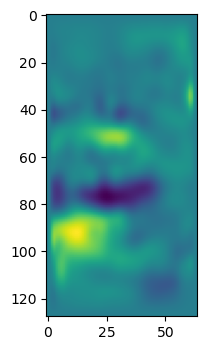

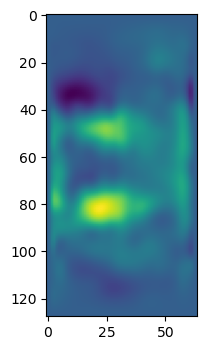

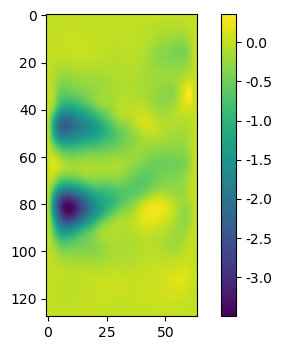

ct shape:torch.Size([1, 1, 128, 128, 64])
ddf shape:torch.Size([1, 3, 128, 128, 64])
ddf max:5.446831703186035 min:-17.627531051635742 mean:-0.18777213990688324
torch.Size([1, 1, 128, 128, 64])
fake t0 shape:(128, 128, 64)
real tn shape:(128, 128, 64)


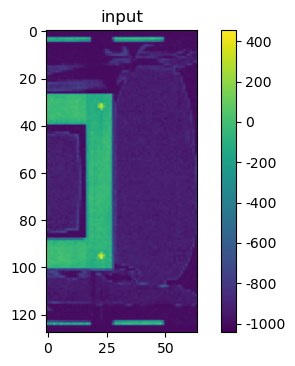

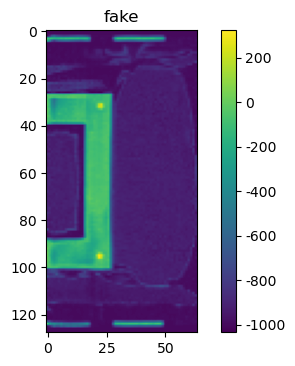

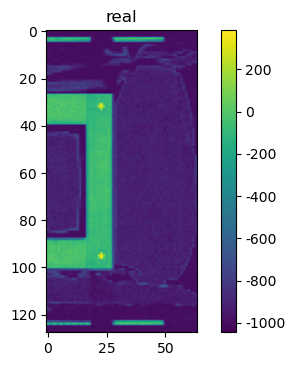

In [6]:
import os
import matplotlib.pyplot as plt
ddf_path = "/dataset1/4dct_0510/transform"

warp = Warp()
dvf2ddf = DVF2DDF()
def sortddf(item):
    return item.split("/")[-1].split(".")[0].split("_ddf")[-1]

files = sorted([os.path.join(ddf_path,file) for file in os.listdir(ddf_path) if ".nii" in file])

# 
pnames = set([file.split("/")[-1].split("_")[0] for file in files])
pnames = sorted(list(pnames))
# print(pnames)
for pname in pnames[150:]:
    index = 5

    # 128 128 53
    real_t0_img = ants.image_read(f"/dataset1/4dct_0510/resampled/{pname}_t0_resampled.nii")
    real_t0_npy = real_t0_img.numpy()
    real_t0_tensor = torch.tensor(real_t0_npy)

    # 128 128 53
    real_tn_img = ants.image_read(f"/dataset1/4dct_0510/resampled/{pname}_t5_resampled.nii")
    real_tn_npy = real_tn_img.numpy()
    real_tn_tensor = torch.tensor(real_tn_npy)

    # 3 128 128 53
    ddf_img = ants.image_read(f"{ddf_path}/{pname}_t{index}_Warp.nii.gz") # _Warp.nii.gz
    ddf_npy = ddf_img.numpy().transpose(3,0,1,2)

    plt.figure(dpi=100)
    plt.imshow(ddf_npy[0,:,50,:])
    plt.show()

    plt.figure(dpi=100)
    plt.imshow(ddf_npy[1,:,50,:])
    plt.show()

    plt.figure(dpi=100)
    plt.imshow(ddf_npy[2,:,50,:])
    plt.colorbar()
    plt.show()
    ddf_tensor = torch.tensor(ddf_npy)#*35./100./2.

    ddf_tensor = torch.unsqueeze(ddf_tensor, dim=0)
    real_t0_tensor = torch.unsqueeze(real_t0_tensor, dim=0)
    real_t0_tensor = torch.unsqueeze(real_t0_tensor, dim=0)
    real_tn_tensor = torch.unsqueeze(real_tn_tensor, dim=0)
    real_tn_tensor = torch.unsqueeze(real_tn_tensor, dim=0)

    print(f"ct shape:{real_tn_tensor.shape}\nddf shape:{ddf_tensor.shape}")
    print(f"ddf max:{ddf_tensor.max()} min:{ddf_tensor.min()} mean:{ddf_tensor.mean()}")

    # ddf_tensor = (ddf_tensor+1000.)/3000.
    # ddf_tensor[ddf_tensor<0]=0
    # ddf_tensor[ddf_tensor>1]=1
    # ddf_tensor_2 = dvf2ddf(ddf_tensor)
    # print(ddf_tensor.shape)
    fake_tn_npy = warp(real_t0_tensor,ddf_tensor)
    print(fake_tn_npy.shape)
    fake_tn_npy = fake_tn_npy[0,0,...].numpy()

    print(f"fake t0 shape:{fake_tn_npy.shape}\nreal tn shape:{real_tn_npy.shape}")
    plt.figure(dpi=100)
    plt.imshow(real_t0_npy[:,50,:])
    plt.title("input")
    plt.colorbar()
    plt.show()

    plt.figure(dpi=100)
    plt.imshow(fake_tn_npy[:,50,:])
    plt.title("fake")
    plt.colorbar()
    plt.show()
    plt.figure(dpi=100)
    plt.imshow(real_tn_npy[:,50,:])
    plt.title("real")
    plt.colorbar()
    plt.show()
    
    # # 128 128 64
    # real_tn_npy = ct_reshape_to_dest(real_tn_npy)

    # # 128 128 64 3
    # ddf_npy = ddf_reshape_to_dest(ddf_npy)
    # print(real_tn_npy.shape)
    # print(ddf_npy.shape)
    break

In [44]:
import ants
fixed = ants.image_read(f"/dataset1/4dct_4/{pname}_t5.nii")*0.01+1000
moving = ants.image_read(f"/dataset1/4dct_4/{pname}_t0.nii")*3+3000

fixed = ants.resample_image(fixed,(128,128,64),True,4)
moving = ants.resample_image(fixed,(128,128,64),True,4)
# mytx = ants.registration(fixed=fixed , moving=moving ,
#                          type_of_transform = 'SyN' )
mywarpedimage = ants.apply_transforms( fixed=fixed, moving=moving,
                                       transformlist=[f"{ddf_path}/{pname}_t{index}.nii.gz"])

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


In [35]:
mywarpedimage

ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (128, 128, 40)
	 Spacing    : (3.9062, 3.9062, 8.0)
	 Origin     : (-249.5117, -447.5117, -979.5)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]

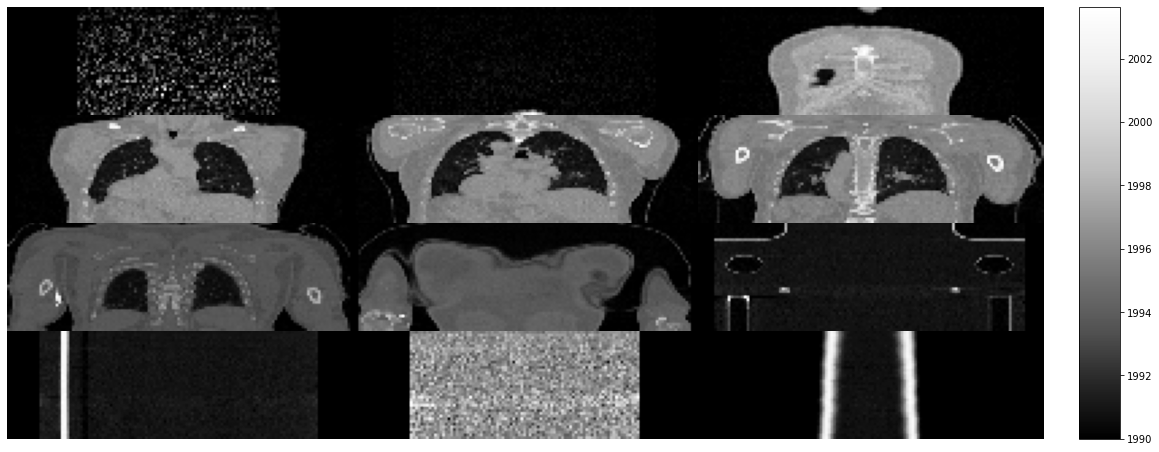

In [43]:
(fixed+1000).plot(axis=1,cbar=True)

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


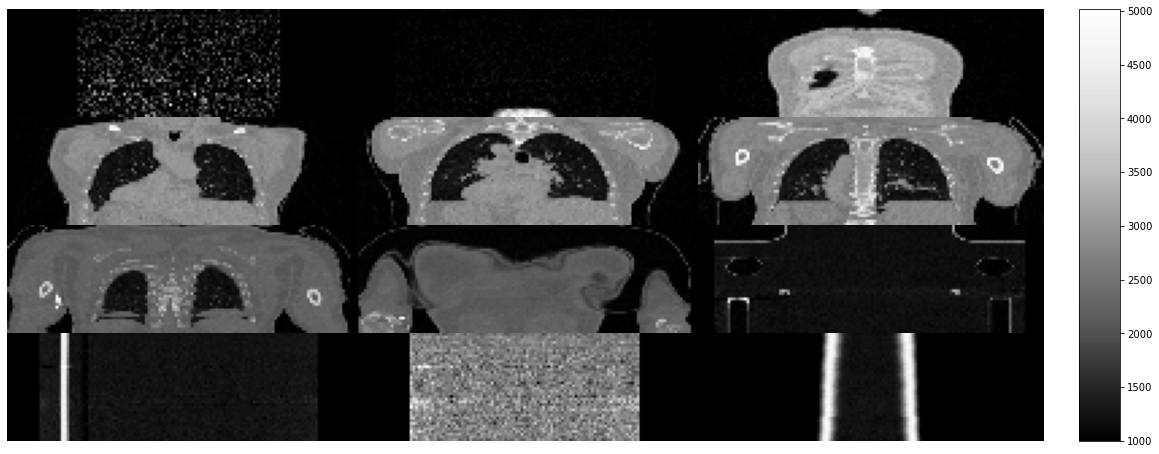

In [39]:
(moving+1000).plot(axis=1,cbar=True)

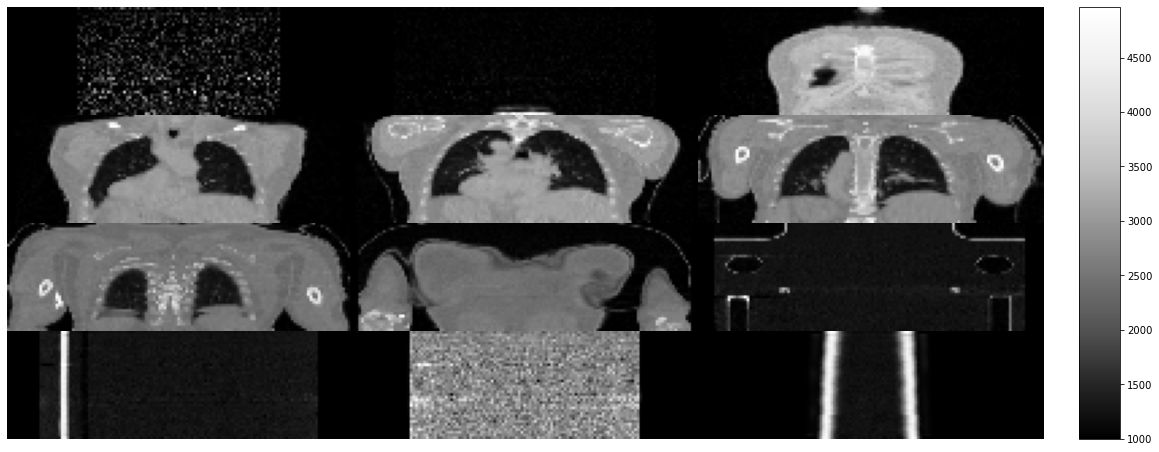

In [41]:
(mywarpedimage+1000).plot(axis=1,cbar=True)

In [51]:

mywarpedgrid = ants.create_warped_grid( moving, grid_directions=(True,True,True),
                        transform=[f"{ddf_path}/{pname}_t{index}.nii.gz"], fixed_reference_image=fixed)


In [52]:
mywarpedgrid

ANTsImage (RAI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (128, 128, 64)
	 Spacing    : (3.9062, 3.9062, 4.9524)
	 Origin     : (-249.5117, -447.5117, -979.5)
	 Direction  : [1. 0. 0. 0. 1. 0. 0. 0. 1.]

`should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.


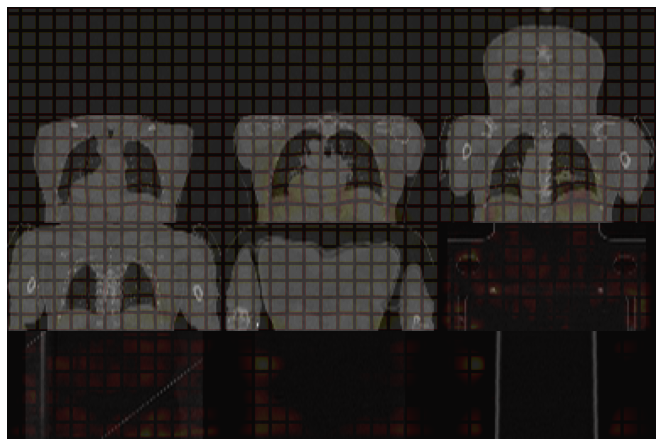

In [61]:
mywarpedgrid.plot(overlay_alpha=0.9,overlay=fixed,axis=1,overlay_cmap='gray',cmap='hot')